In [1]:
!uv pip install datasets pandas numpy matplotlib seaborn pillow kagglehub

Using Python 3.12.12 environment at: /usr
Audited 7 packages in 341ms


# **Loading all the datasets**

In [2]:
import kagglehub
sroie_dataset = kagglehub.dataset_download("urbikn/sroie-datasetv2")

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.


In [3]:
find_it_again_dataset = kagglehub.dataset_download("nikita2998/find-it-again-dataset")

100%|██████████| 643M/643M [00:07<00:00, 84.3MB/s]

Extracting files...


In [4]:
from datasets import load_dataset

cord_dataset = load_dataset("naver-clova-ix/cord-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/27.0 [00:00<?, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-b4aaeceff1d90e(…):   0%|          | 0.00/490M [00:00<?, ?B/s]

data/train-00001-of-00004-7dbbe248962764(…):   0%|          | 0.00/441M [00:00<?, ?B/s]

...

data/validation-00000-of-00001-cc3c5779f(…):   0%|          | 0.00/242M [00:00<?, ?B/s]

data/test-00000-of-00001-9c204eb3f4e1179(…):   0%|          | 0.00/234M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/800 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/100 [00:00<?, ? examples/s]

# **Exploring the datasets**

## Kaggle dataset


Understanding kaggle dataset dir & files struture


In [5]:
from collections import defaultdict
import os

def group_files_by_dir(path: str):
    # we will group files by their dir
    # where each key is going to be a dir
    # and value is the list of files in that dir
    grouped = defaultdict(list)
    for root, dirs, files in os.walk(path):
        for file in files:
            grouped[root].append(file)
    return grouped

sroie_group = group_files_by_dir(sroie_dataset)
find_it_again_group = group_files_by_dir(find_it_again_dataset)

print("Find it again dirs")
for key in find_it_again_group:
    print(key)
print("SROIE dirs")
for key in sroie_group:
    print(key)


Find it again dirs
/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2
/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/val
/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/train
/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/test
SROIE dirs
/kaggle/input/sroie-datasetv2/SROIE2019/layoutlm-base-uncased
/kaggle/input/sroie-datasetv2/SROIE2019/test/box
/kaggle/input/sroie-datasetv2/SROIE2019/test/entities
/kaggle/input/sroie-datasetv2/SROIE2019/test/img
/kaggle/input/sroie-datasetv2/SROIE2019/train/box
/kaggle/input/sroie-datasetv2/SROIE2019/train/entities
/kaggle/input/sroie-datasetv2/SROIE2019/train/img


Defining helpers

In [6]:
from pathlib import Path
from PIL import Image
from collections import Counter
import matplotlib.pyplot as plt
import json

def check_extension_and_open(path: str):
    # checking extension
    ext = Path(path).suffix.lower()

    try:
        if ext == ".txt": # we read first 5 lines of text fiels to understand its structure
            with open(path, 'r', encoding='utf-8') as f:
                lines = f.readlines()
                print("Content (first 5 lines):")
                for i, line in enumerate(lines[:5]):
                    print(f"{i+1}: {line.strip()}")
                print(f"Total lines: {len(lines)}")
        elif ext == ".json": # for json we just load the whole object
            with open(path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                if isinstance(data, dict): # for dicts objects we print count and keys
                    print(f"JSON object with {len(data)} items & keys: \n{list(data.keys())}")
                elif isinstance(data, list): # for list objects we print count and first 5 items
                    print(f"JSON array with {len(data)} items")
                    print("Content (first 5 itmes):")
                    for i, item in enumerate(data[:5]):
                        print(f"{i+1}: {item}")
                else:
                    print(f"JSON content is of type: {type(data).__name__}")
        elif ext in [".jpg", ".jpeg", ".png"]: # only supporting these format
            with Image.open(path) as img:
                print(f"Image size: {img.size}, mode: {img.mode}") # basic image info
                plt.imshow(img)
                plt.axis('off') # remove axes
                plt.title(Path(path).name) # just to differentiate between images
                plt.show()
        else:
            print("Unsupported file type")
    except json.JSONDecodeError:
        print(f"Error occurred: Could not decode JSON from {path}")
        print(f"Previewing as text (first 50 chars):")
        with open(path, 'r', encoding='utf-8') as f:
            print(f.read()[:50])
    except Exception as e:
        print(f"Error occurred while opening {path}: {e}")


def peak(dir_group):
    # peaking a file from each dir
    for key in dir_group:
        print(f"Peaking {key}")
        # first item is enough to let us understand the type and content
        if dir_group[key]: # just to make sure we have items inside
            first_item_filename = dir_group[key][0]
            print(f"first file: {first_item_filename}")
            check_extension_and_open(os.path.join(key, first_item_filename))
        else:
            print("Found not items in dir")

def peak_all_files(dir_path):
    # peaking a file from each dir
    print(f"Peaking {dir_path}")
    for file in os.listdir(dir_path):
        print(f"Reading {file}")
        file_path = os.path.join(dir_path, file)
        check_extension_and_open(file_path)

def analyze_file_distribution(grouped_files_dict):
    for directory, files in grouped_files_dict.items():
        extension_counts = Counter()
        for file_name in files:
            # checking extension
            ext = Path(file_name).suffix.lower()
            if ext:
                extension_counts[ext] += 1
            else:
                extension_counts["no_extension"] += 1 #  files without an extension

        print(f"\nDirectory: {directory}")
        if extension_counts:
            for ext, count in extension_counts.items():
                print(f"  {ext}: {count}")
        else:
            print("No files found or no extensions to count.")

### Sroie dataset analysis

analyzing the distribution & data preview



Analyzing sroie dataset file distribution

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/layoutlm-base-uncased
  .json: 3
  .bin: 2
  .txt: 1

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/test/box
  .txt: 347

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/test/entities
  .txt: 347

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/test/img
  .jpg: 347

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/train/box
  .txt: 626

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/train/entities
  .txt: 626

Directory: /kaggle/input/sroie-datasetv2/SROIE2019/train/img
  .jpg: 626

Previewing sroie dataset
Peaking /kaggle/input/sroie-datasetv2/SROIE2019/layoutlm-base-uncased
first file: config.json
JSON object with 22 items & keys: 
['attention_probs_dropout_prob', 'finetuning_task', 'hidden_act', 'hidden_dropout_prob', 'hidden_size', 'initializer_range', 'intermediate_size', 'is_decoder', 'layer_norm_eps', 'max_position_embeddings', 'max_2d_position_embeddings', 'num_attent

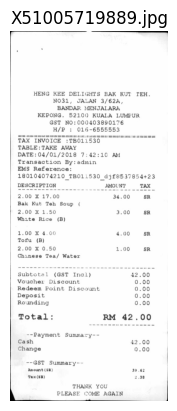

Peaking /kaggle/input/sroie-datasetv2/SROIE2019/train/box
first file: X51005705760.txt
Content (first 5 lines):
1: 216,255,565,255,565,351,216,351,MYDIN
2: 152,355,623,355,623,411,152,411,TRI SHAAS SDN BHD (728515-M)
3: 233,402,556,402,556,451,233,451,MYDIN MART SRI MUDA
4: 75,439,689,439,689,495,75,495,4-20, JALAN RIA 25/62 TAMAN SRI MUDA
5: 88,483,683,483,683,534,88,534,SEKSYEN 25, 40400 SHAH ALAM SELANGOR
Total lines: 103
Peaking /kaggle/input/sroie-datasetv2/SROIE2019/train/entities
first file: X51005705760.txt
Content (first 5 lines):
1: {
2: "company": "TRI SHAAS SDN BHD",
3: "date": "10/08/2017",
4: "address": "4-20, JALAN RIA 25/62 TAMAN SRI MUDA SEKSYEN 25, 40400 SHAH ALAM SELANGOR",
5: "total": "21.40"
Total lines: 6
Peaking /kaggle/input/sroie-datasetv2/SROIE2019/train/img
first file: X51007231344.jpg
Image size: (4961, 7016), mode: L


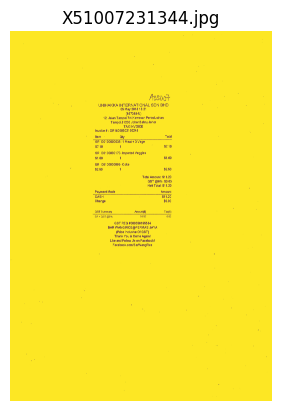

In [7]:
print("\n" + "=" * 50)
print("Analyzing sroie dataset file distribution")
print("=" * 50)
analyze_file_distribution(sroie_group)

print("\n" + "=" * 50)
print("Previewing sroie dataset")
print("=" * 50)
peak(sroie_group)

Loading Entities & OCR previewing

From the previous analysis and dataset description on Kaggle, the entities dir, seems to hold key data regarding receipts annotations.

So we are going to load them into a `DataFrame` for easy analysis

In [8]:
import pandas as pd

def load_entities(dir_path):
    records = []
    for filepath in sorted(Path(dir_path).glob("*.txt")): # loading only text files
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
            data["receipt_id"] = filepath.stem # filename without ext
            records.append(data)
        except json.JSONDecodeError:
            print(f"Error occurred: Could not decode JSON from {filepath}")
        except Exception as e:
            print(f"Error occurred while opening {filepath}: {e}")
    return pd.DataFrame(records)

# sroie_group.keys() results all the dir within the sorie dataset files
# we are only interested with entities dir
# this will give us 2 dir -> train/entities and test/entities
entities_path = list(filter(lambda x: "entities" in x, sroie_group.keys()))
# due to sorting, train path comes first
entities_path.sort(key=lambda x: 0 if "train" in x else 1)

sroie_train_df = load_entities(entities_path[0])
sroie_test_df = load_entities(entities_path[1])

print(f"train entities len {len(sroie_train_df)}")
print(f"test entities len {len(sroie_test_df)}")
sroie_train_df.head()


train entities len 626
test entities len 347


,company,date,address,total,receipt_id
0,BOOK TA .K (TAMAN DAYA) SDN BHD,25/12/2018,"NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...",9.00,X00016469612
1,INDAH GIFT & HOME DECO,19/10/2018,"27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...",60.30,X00016469619
2,MR D.I.Y. (JOHOR) SDN BHD,12-01-19,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",33.90,X00016469620
3,YONGFATT ENTERPRISE,25/12/2018,NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU,80.90,X00016469622
4,MR D.I.Y. (M) SDN BHD,18-11-18,"LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...",30.90,X00016469623


Let's visualize ocr data on real receipt image

In [9]:
# selecting a smaple from our train
print(sroie_train_df.head())
sample_receipt_id = sroie_train_df['receipt_id'].iloc[0]
print(f"Selected sample_receipt_id: {sample_receipt_id}")

                           company        date  \
0  BOOK TA .K (TAMAN DAYA) SDN BHD  25/12/2018   
1           INDAH GIFT & HOME DECO  19/10/2018   
2        MR D.I.Y. (JOHOR) SDN BHD    12-01-19   
3              YONGFATT ENTERPRISE  25/12/2018   
4            MR D.I.Y. (M) SDN BHD    18-11-18   

                                             address  total    receipt_id  
0  NO.53 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 8...   9.00  X00016469612  
1  27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JO...  60.30  X00016469619  
2  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  33.90  X00016469620  
3       NO 122.124. JALAN DEDAP 13 81100 JOHOR BAHRU  80.90  X00016469622  
4  LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERI...  30.90  X00016469623  
Selected sample_receipt_id: X00016469612


In [10]:
# finding training image directory from sroie_group
image_dir = list(filter(lambda x: 'train/img' in x, sroie_group.keys()))[0]

# constructing full path for image
image_path = os.path.join(image_dir, f'{sample_receipt_id}.jpg')

# finding training bounding box directory from sroie_group
box_dir = list(filter(lambda x: 'train/box' in x, sroie_group.keys()))[0]

# constructing full path for the bounding box
box_path = os.path.join(box_dir, f'{sample_receipt_id}.txt')

print(f"Image path: {image_path}")
print(f"Bounding box path: {box_path}")

Image path: /kaggle/input/sroie-datasetv2/SROIE2019/train/img/X00016469612.jpg
Bounding box path: /kaggle/input/sroie-datasetv2/SROIE2019/train/box/X00016469612.txt


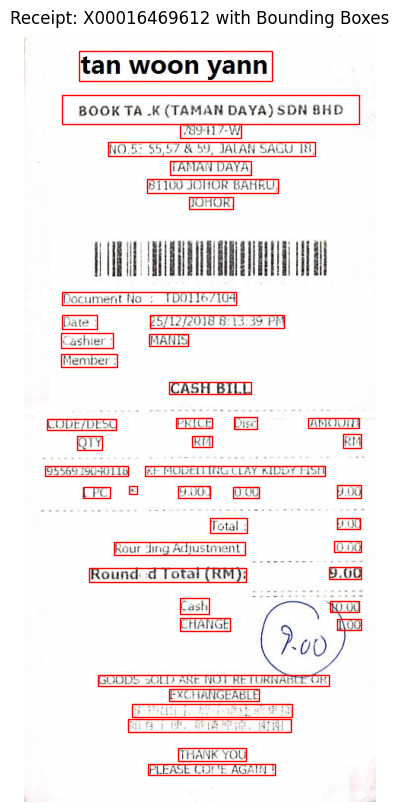

First 5 words and boxes from /kaggle/input/sroie-datasetv2/SROIE2019/train/box/X00016469612.txt:
Word: 'TAN WOON YANN', Box: [72, 25, 326, 64]
Word: 'BOOK TA .K(TAMAN DAYA) SDN BND', Box: [50, 82, 440, 121]
Word: '789417-W', Box: [205, 121, 285, 139]
Word: 'NO.53 55,57 & 59, JALAN SAGU 18,', Box: [110, 144, 383, 163]
Word: 'TAMAN DAYA,', Box: [192, 169, 299, 187]


In [11]:
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

def read_box_file(box_path):
    boxes = []
    words = []
    with open(box_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) >= 8:
                # coordinate are x1, y1, x2, y2, x3, y3, x4, y4
                # it is drawn in a clock-wise manner
                x_coords = [int(parts[0]), int(parts[2]), int(parts[4]), int(parts[6])]
                y_coords = [int(parts[1]), int(parts[3]), int(parts[5]), int(parts[7])]

                min_x = min(x_coords) # min x value is always at top-left or bottom-left (start and end)
                min_y = min(y_coords) # min y is always at top-left or top-right
                max_x = max(x_coords) # max x is always at top-right and bottom-right
                max_y = max(y_coords) # finally this will be at bottom right and bottom-left

                boxes.append([min_x, min_y, max_x, max_y])
                words.append(','.join(parts[8:]).strip())
    return boxes, words

image = Image.open(image_path)

boxes, words = read_box_file(box_path)

# displaying
plt.figure(figsize=(10, 10))
plt.imshow(image)
# getting the current axes (fig)
ax = plt.gca()

# draw
for box, word in zip(boxes, words):
    x1, y1, x2, y2 = box
    rect = plt.Rectangle(xy=(x1, y1), width=x2 - x1, height=y2 - y1, linewidth=1, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    # ax.text(x1, y1 - 5, word, color='blue', fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5))

plt.axis('off')
plt.title(f'Receipt: {sample_receipt_id} with Bounding Boxes')
plt.show()

print(f"First 5 words and boxes from {box_path}:")
for i in range(min(5, len(words))):
    print(f"Word: '{words[i]}', Box: {boxes[i]}")

Cleaning an preprocessing

In [12]:
# checking null values
print("train:")
print(sroie_train_df.isnull().sum())
print("test:")
print(sroie_test_df.isnull().sum())

train:
company       0
date          0
address       1
total         0
receipt_id    0
dtype: int64
test:
company       0
date          0
address       0
total         0
receipt_id    0
dtype: int64


The `address` column in train has one missing value. Let's fill this with an empty string.

In [13]:
sroie_train_df['address'] = sroie_train_df['address'].fillna('')
sroie_train_df.isnull().sum()

,0
company,0
date,0
address,0
total,0
receipt_id,0


Checking `total` field type if it needs conversion

In [14]:
print(sroie_train_df['total'].dtype)
print(sroie_test_df['total'].dtype)

object
object


Let's inspect it

In [15]:
sroie_test_df['total'].head()

,total
0,193.00
1,170.00
2,436.20
3,4.90
4,38.90


Let's convert it to string then to float since most are string

In [16]:
import numpy as np

def clean_total_columns(df):
    try:
        df['total'] = df['total'].astype(str)
        df['total'] = pd.to_numeric(df['total'])
        return df
    except Exception as e:
        print(f"Error occurred while cleaning 'total' column: {e}")
        return df

sroie_train_df = clean_total_columns(sroie_train_df)
sroie_test_df = clean_total_columns(sroie_test_df)


Error occurred while cleaning 'total' column: Unable to parse string "$8.20" at position 30
Error occurred while cleaning 'total' column: Unable to parse string "$8.20" at position 20


Let's remove any '$' prefix

In [17]:
import numpy as np

def clean_total_columns(df):
    try:
        df['total'] = df['total'].astype(str)
        df['total'] = df['total'].str.replace("$", "")
        df['total'] = pd.to_numeric(df['total'])
        return df
    except Exception as e:
        print(f"Error occurred while cleaning 'total' column: {e}")
        return df

sroie_train_df = clean_total_columns(sroie_train_df)
sroie_test_df = clean_total_columns(sroie_test_df)

Error occurred while cleaning 'total' column: Unable to parse string "RM 3.90" at position 81
Error occurred while cleaning 'total' column: Unable to parse string "RM7.42" at position 75


new error, let's remove 'RM'

In [18]:
import numpy as np

def clean_total_columns(df):
    try:
        df['total'] = df['total'].astype(str)
        df['total'] = df['total'].str.replace("$", "")
        df['total'] = df['total'].str.replace("RM", "")
        df['total'] = pd.to_numeric(df['total'])
        return df
    except Exception as e:
        print(f"Error occurred while cleaning 'total' column: {e}")
        return df

sroie_train_df = clean_total_columns(sroie_train_df)
sroie_test_df = clean_total_columns(sroie_test_df)

Error occurred while cleaning 'total' column: Unable to parse string "1,007.50" at position 350


Let's not give up and remove ','

In [19]:
import numpy as np

def clean_total_columns(df):
    try:
        df['total'] = df['total'].astype(str)
        df['total'] = df['total'].str.replace("$", "")
        df['total'] = df['total'].str.replace("RM", "")
        df['total'] = df['total'].str.replace(",", "")
        df['total'] = pd.to_numeric(df['total'])
        return df
    except Exception as e:
        print(f"Error occurred while cleaning 'total' column: {e}")
        return df

sroie_train_df = clean_total_columns(sroie_train_df)
sroie_test_df = clean_total_columns(sroie_test_df)

Finally it works let's make sure

In [20]:
print("sroie_train_df 'total' column dtype:")
print(sroie_train_df['total'].dtype)
print("\nsroie_train_df 'total' column head:")
print(sroie_train_df['total'].head())

print("\n\nsroie_test_df 'total' column dtype:")
print(sroie_test_df['total'].dtype)
print("\nsroie_test_df 'total' column head:")
print(sroie_test_df['total'].head())

sroie_train_df 'total' column dtype:
float64

sroie_train_df 'total' column head:
0     9.0
1    60.3
2    33.9
3    80.9
4    30.9
Name: total, dtype: float64


sroie_test_df 'total' column dtype:
float64

sroie_test_df 'total' column head:
0    193.0
1    170.0
2    436.2
3      4.9
4     38.9
Name: total, dtype: float64


### Find-It-Again dataset analysis


Analyzing sroie dataset file distribution

Directory: /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2
  .txt: 3

Directory: /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/val
  .txt: 192
  .png: 192

Directory: /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/train
  .png: 577
  .txt: 577

Directory: /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/test
  .txt: 218
  .png: 218

Previewing sroie dataset
Peaking /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2
first file: train.txt
Content (first 5 lines):
1: image,digital annotation,handwritten annotation,forged,forgery annotations
2: X00016469622.png,1,1,1,"{'filename': 'X00016469622.png', 'size': 230726, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 248, 'y': 459, 'width': 13, 'height': 18}, 'region_attributes': {'Modified area': {'CPI': True}, 'Enti

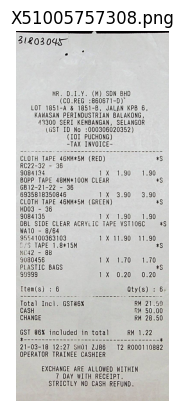

Peaking /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/test
first file: X51006556726.txt
Content (first 5 lines):
1: GARDENIA BAKERIES (KL) SDN BHD (139386 X)
2: LOT 3, JALAN PELABUR 23/1,
3: 40300 SHAH ALAM, SELANGOR.
4: TEL: 03- 55423228
5: GST ID: 000381399040
Total lines: 72


In [21]:
print("\n" + "=" * 50)
print("Analyzing sroie dataset file distribution")
print("=" * 50)
analyze_file_distribution(find_it_again_group)

print("\n" + "=" * 50)
print("Previewing sroie dataset")
print("=" * 50)
peak(find_it_again_group)

Let's further discover the findit2 subdirectory

In [22]:
fintit2_path = list(filter(lambda x: x.endswith('findit2'), find_it_again_group.keys()))[0]
print(fintit2_path)
peak_all_files(fintit2_path)

/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2
Peaking /root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2
Reading val
Unsupported file type
Reading train
Unsupported file type
Reading train.txt
Content (first 5 lines):
1: image,digital annotation,handwritten annotation,forged,forgery annotations
2: X00016469622.png,1,1,1,"{'filename': 'X00016469622.png', 'size': 230726, 'regions': [{'shape_attributes': {'name': 'rect', 'x': 248, 'y': 459, 'width': 13, 'height': 18}, 'region_attributes': {'Modified area': {'CPI': True}, 'Entity type': 'Product', 'Original area': 'no'}}, {'shape_attributes': {'name': 'rect', 'x': 405, 'y': 342, 'width': 13, 'height': 17}, 'region_attributes': {'Modified area': {'None': True}, 'Original area': 'yes', 'Entity type': 'Metadata'}}, {'shape_attributes': {'name': 'rect', 'x': 345, 'y': 461, 'width': 9, 'height': 16}, 'region_attributes': {'Modified area': {'CPI': True}, 'Entity type': 'Produ

We could notice that those files are actually csv files, let's open them

Loading train as DF


In [23]:

train_file = list(Path(fintit2_path).glob("train.txt"))[0]
print(train_file)
# any since we are just discovering
forgery_df = pd.read_csv(train_file)
forgery_df.head()

/root/.cache/kagglehub/datasets/nikita2998/find-it-again-dataset/versions/1/findit2/train.txt


,image,digital annotation,handwritten annotation,forged,forgery annotations
0,X00016469622.png,1,1,1,"{'filename': 'X00016469622.png', 'size': 23072..."
1,X00016469623.png,1,1,0,0
2,X00016469670.png,1,1,0,0
3,X00016469671.png,1,1,0,0
4,X00016469672.png,1,1,0,0


we can notice that we can easily refer to the image via `image` or `forgery annotations`'s filename field. Also the `forged` field shows basic info (forged 1 or not 0) while the `forgery annotations` shows detailed information regarding the forged receipts

Visualization

In [24]:
print("Distribution of forged vs. genuine receipts:")
forgery_distribution = forgery_df['forged'].value_counts()
print(forgery_distribution)

Distribution of forged vs. genuine receipts:
forged
0    483
1     94
Name: count, dtype: int64


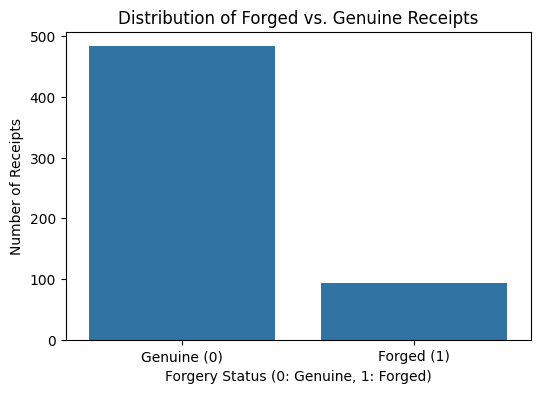

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=forgery_distribution.index, y=forgery_distribution.values)
plt.title('Distribution of Forged vs. Genuine Receipts')
plt.xlabel('Forgery Status (0: Genuine, 1: Forged)')
plt.ylabel('Number of Receipts')
plt.xticks(ticks=[0, 1], labels=['Genuine (0)', 'Forged (1)'])
plt.show()

let's get deeper into the `forgery annotation` by parsing it to json and extracting what are the forgery types

In [26]:
import pandas as pd
import json
import ast


def parse_literal_safe(literal_str):
    try:
        if isinstance(literal_str, str) and literal_str.strip() != '0':
            stripped_str = literal_str.strip('"').strip("' ") # handle both "{}" and '{ }' cases
            return ast.literal_eval(stripped_str)
        else:
            return None
    except (ValueError, SyntaxError) as e:
        print(f"Could not evaluate literal: {e} for {literal_str[:100]}...")
        return None
    except Exception as e:
        print(f"An unexpected error occurred while parsing: {e} for {literal_str[:100]}...")
        return None

# parsing all the annotation
forgery_df['parsed_annotations'] = forgery_df['forgery annotations'].apply(parse_literal_safe)

# only get the parsed forged annotation
forged_with_annotations_df = forgery_df[(forgery_df['forged'] == 1) & (forgery_df['parsed_annotations'].notna())]

print("DataFrame head with parsed annotations (forged receipts only):")
print(forged_with_annotations_df[['image', 'forged', 'parsed_annotations']].head())
print(f"\nNumber of forged receipts with valid annotations: {len(forged_with_annotations_df)}")

print("full sample")
sample = forged_with_annotations_df.iloc[0]['parsed_annotations']
print(json.dumps(sample, indent=4))

DataFrame head with parsed annotations (forged receipts only):
               image  forged  \
0   X00016469622.png       1   
6   X51005230617.png       1   
25  X51005361906.png       1   
30  X51005361946.png       1   
32  X51005365179.png       1   

                                   parsed_annotations  
0   {'filename': 'X00016469622.png', 'size': 23072...  
6   {'filename': 'X51005230617.png', 'size': 79672...  
25  {'filename': 'X51005361906.png', 'size': 38813...  
30  {'filename': 'X51005361946.png', 'size': 77602...  
32  {'filename': 'X51005365179.png', 'size': 40184...  

Number of forged receipts with valid annotations: 93
full sample
{
    "filename": "X00016469622.png",
    "size": 230726,
    "regions": [
        {
            "shape_attributes": {
                "name": "rect",
                "x": 248,
                "y": 459,
                "width": 13,
                "height": 18
            },
            "region_attributes": {
                "Modified area"

From the previous sample we can see that regions contains objects each object represent information about the forgery for the corresponding receipt. For better understanding, let's plot those areas that have been forged.

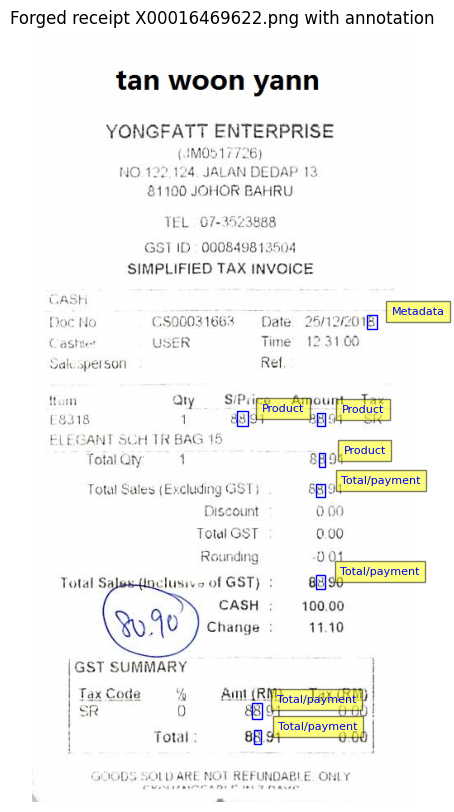

In [27]:
image_path = os.path.join(fintit2_path, "train",sample['filename'])

image = Image.open(image_path)

# displaying
plt.figure(figsize=(10, 10))
plt.imshow(image)

# getting the current axes (fig)
ax = plt.gca()

# draw
for obj in sample['regions']:
    x, y, width, height = obj['shape_attributes']['x'], obj['shape_attributes']['y'], obj['shape_attributes']['width'], obj['shape_attributes']['height']
    rect = plt.Rectangle(xy=(x, y), width=width, height=height, edgecolor='b', facecolor='none')
    ax.add_patch(rect)
    annotation = obj['region_attributes']['Entity type']
    ax.text(x + 30, y, annotation, color='blue', fontsize=8, bbox=dict(facecolor='yellow', alpha=0.5))

plt.axis('off')
plt.title(f'Forged receipt {sample['filename']} with annotation')
plt.show()

Lastly let's print & plot the distribution of forgery types

In [28]:
from collections import Counter

forgery_types = []
for index, row in forged_with_annotations_df.iterrows():
    annotations = row['parsed_annotations']
    if annotations and 'regions' in annotations:
        for region in annotations['regions']:
            if 'region_attributes' in region and 'Entity type' in region['region_attributes']:
                forgery_types.append(region['region_attributes']['Entity type'])

forgery_type_counts = Counter(forgery_types)

print("\nDistribution of Forgery Entity Types:")
for item, count in forgery_type_counts.most_common():
    print(f"- {item}: {count}")


Distribution of Forgery Entity Types:
- Total/payment: 188
- Product: 84
- Metadata: 69
- Company: 19
- Other: 17


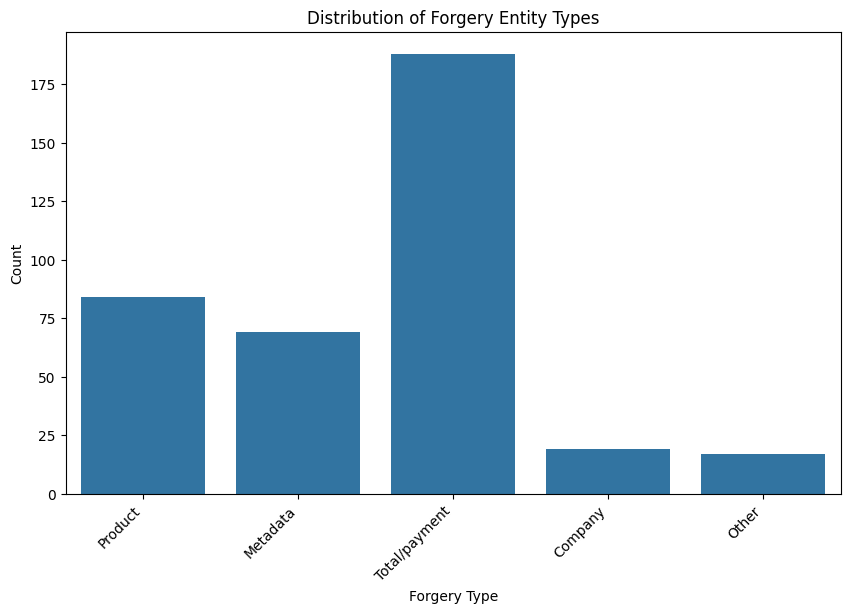

In [29]:
import seaborn as sns

# converting the forgery_type_counts Counter object into a pandas Series for plotting.
forgery_type_counts_series = pd.Series(forgery_type_counts)

plt.figure(figsize=(10, 6))
sns.barplot(x=forgery_type_counts_series.index, y=forgery_type_counts_series.values)
plt.title('Distribution of Forgery Entity Types')
plt.xlabel('Forgery Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.show()


## Hugging Face dataset

### CORD dataset

Now let's undetstand the cord dataset

In [30]:
print("CORD DatasetDict structure:")
print(cord_dataset)

print("\nFeatures of the 'train' split:")
print(cord_dataset['train'].features)

print("\nSample entry from the 'train' split:")
print(cord_dataset['train'][0])

CORD DatasetDict structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 800
    })
    validation: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
    test: Dataset({
        features: ['image', 'ground_truth'],
        num_rows: 100
    })
})

Features of the 'train' split:
{'image': Image(mode=None, decode=True), 'ground_truth': Value('string')}

Sample entry from the 'train' split:
{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=864x1296 at 0x7BCFA4C04500>, 'ground_truth': '{"gt_parse": {"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1

let's view what is insdie the ground_trurh in a proper format

In [31]:
# getting the first sample
ground_truth_str = cord_dataset['train'][0]['ground_truth']

parsed_ground_truth = json.loads(ground_truth_str)

print("Pretty-printed ground_truth for the first sample:")
print(json.dumps(parsed_ground_truth, indent=4))

Pretty-printed ground_truth for the first sample:
{
    "gt_parse": {
        "menu": [
            {
                "nm": "Nasi Campur Bali",
                "cnt": "1 x",
                "price": "75,000"
            },
            {
                "nm": "Bbk Bengil Nasi",
                "cnt": "1 x",
                "price": "125,000"
            },
            {
                "nm": "MilkShake Starwb",
                "cnt": "1 x",
                "price": "37,000"
            },
            {
                "nm": "Ice Lemon Tea",
                "cnt": "1 x",
                "price": "24,000"
            },
            {
                "nm": "Nasi Ayam Dewata",
                "cnt": "1 x",
                "price": "70,000"
            },
            {
                "nm": "Free Ice Tea",
                "cnt": "3 x",
                "price": "0"
            },
            {
                "nm": "Organic Green Sa",
                "cnt": "1 x",
                "price": "65

We could see from the previous output a very important information resulted from the `ground_truth` field.

key objects:
- under **'gt_parse'** we have menu obj (cotnains name, price, count) of products, subtotal obj (various charges), and total obj (final price)

- under **'meta'** it contains meta data about the receipt image
- **'valid_line'** contains all the info about the OCR and it categories

Now let's plot

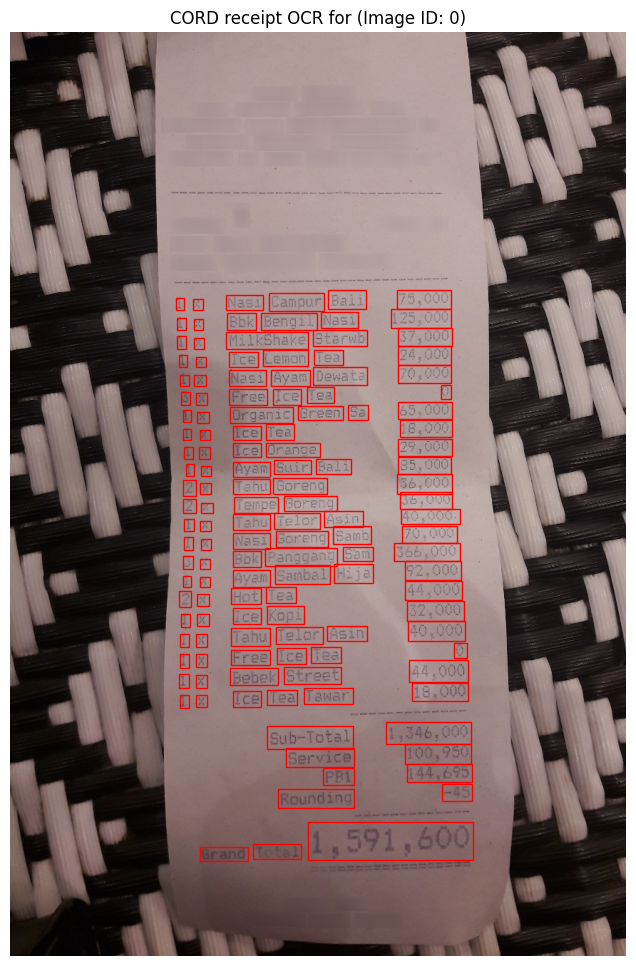

In [32]:
sample_cord_entry = cord_dataset['train'][0]

image = sample_cord_entry['image']
ground_truth_str = sample_cord_entry['ground_truth']
parsed_ground_truth = json.loads(ground_truth_str)

# this contains all the ocr box locations
valid_lines = parsed_ground_truth.get('valid_line')

plt.figure(figsize=(12, 12))
plt.imshow(image)
ax = plt.gca()

for line_entry in valid_lines:
    category = line_entry.get('category')
    # get the ocr info
    for word_entry in line_entry.get('words'):
        text = word_entry.get('text')
        quad = word_entry.get('quad')

        if quad:
            x_coords = [quad['x1'], quad['x2'], quad['x3'], quad['x4']]
            y_coords = [quad['y1'], quad['y2'], quad['y3'], quad['y4']]

            min_x = min(x_coords)
            max_x = max(x_coords)
            min_y = min(y_coords)
            max_y = max(y_coords)


            rect = plt.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y,
                                 linewidth=1, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # we could add the text from the words object but its enough
            # ax.text(min_x, min_y - 5, f'{category}: {text}', color='blue', fontsize=6,
            #         bbox=dict(facecolor='yellow', alpha=0.5))

plt.axis('off')
plt.title(f"CORD receipt OCR for (Image ID: {parsed_ground_truth['meta']['image_id']})")
plt.show()


let's compute distribution stats across the dataset

CORD split sizes:
  train: 800 samples
  validation: 100 samples
  test: 100 samples

CORD train field completeness:
  has_total:    779 / 800 (97.4%)
  has_menu:     800 / 800 (100.0%)

Image size stats (train):
        width  height
count   800.0   800.0
mean    997.1  1573.3
std     544.5   993.6
min     204.0   364.0
25%     576.0   864.0
50%     864.0  1296.0
75%    1080.0  1478.0
max    3024.0  4224.0


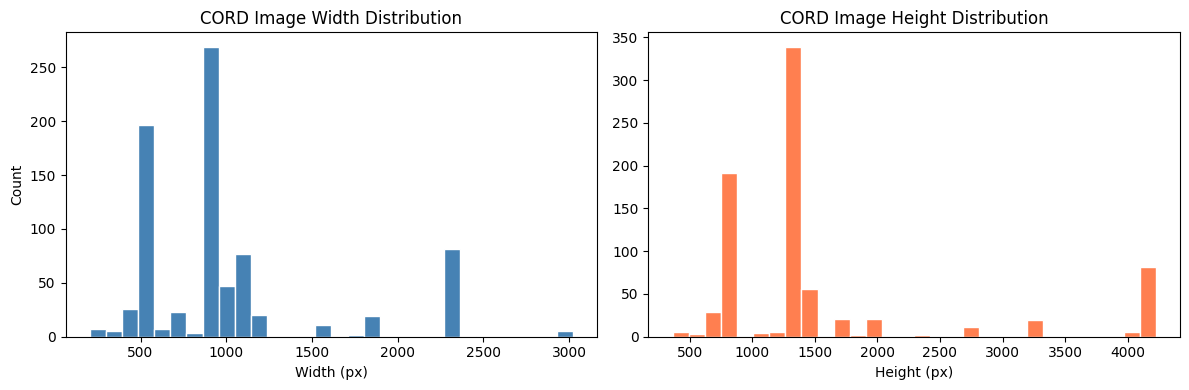

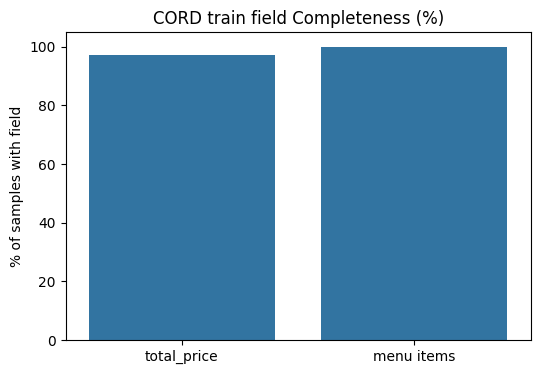

In [33]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("CORD split sizes:")
for split in cord_dataset:
    print(f"  {split}: {len(cord_dataset[split])} samples")

cord_records = []
for entry in cord_dataset['train']:
    gt = json.loads(entry['ground_truth'])
    gt_parse = gt.get('gt_parse', {})

    # total
    total_obj = gt_parse.get('total', {})
    total_price = total_obj.get('total_price', None) if isinstance(total_obj, dict) else None

    # image size
    img = entry['image']
    width, height = img.size

    cord_records.append({
        'width': width,
        'height': height,
        'has_total': total_price is not None,
        'has_menu': bool(gt_parse.get('menu')),
    })

cord_df = pd.DataFrame(cord_records)

print(f"\nCORD train field completeness:")
print(f"  has_total:    {cord_df['has_total'].sum()} / {len(cord_df)} ({cord_df['has_total'].mean()*100:.1f}%)")
print(f"  has_menu:     {cord_df['has_menu'].sum()} / {len(cord_df)} ({cord_df['has_menu'].mean()*100:.1f}%)")

print(f"\nImage size stats (train):")
print(cord_df[['width', 'height']].describe().round(1))

# plotting image distrib
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(cord_df['width'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('CORD Image Width Distribution')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')

axes[1].hist(cord_df['height'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('CORD Image Height Distribution')
axes[1].set_xlabel('Height (px)')

plt.tight_layout()
plt.show()

# completness plotting
completeness = {
    'total_price': cord_df['has_total'].mean(),
    'menu items': cord_df['has_menu'].mean(),
}
plt.figure(figsize=(6, 4))
sns.barplot(x=list(completeness.keys()), y=[v*100 for v in completeness.values()])
plt.title('CORD train field Completeness (%)')
plt.ylabel('% of samples with field')
plt.ylim(0, 105)
plt.show()


Now let's look at category freq distribution

Top 15 CORD OCR categories:
menu.nm                     2100
menu.price                  2093
menu.cnt                    1903
total.total_price            784
menu.unitprice               621
sub_total.subtotal_price     541
total.cashprice              526
total.changeprice            502
sub_total.tax_price          362
menu.sub.nm                  319
total.menuqty_cnt            233
menu.sub.cnt                 142
total.creditcardprice        124
menu.sub.price               123
sub_total.etc                112
dtype: int64


/tmp/ipykernel_349/3255781414.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_series.head(15).index, y=cat_series.head(15).values, palette='muted')


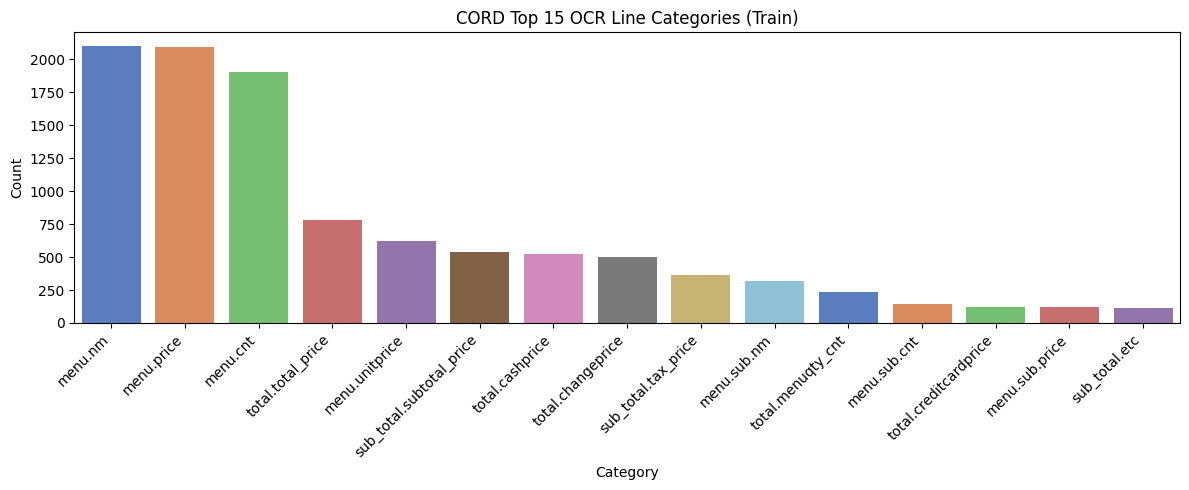

In [34]:
from collections import Counter

category_counts = Counter()
for entry in cord_dataset['train']:
    gt = json.loads(entry['ground_truth'])
    for line in gt.get('valid_line', []):
        category_counts[line.get('category', 'unknown')] += 1

cat_series = pd.Series(category_counts).sort_values(ascending=False)
print("Top 15 CORD OCR categories:")
print(cat_series.head(15))

plt.figure(figsize=(12, 5))
sns.barplot(x=cat_series.head(15).index, y=cat_series.head(15).values, palette='muted')
plt.title('CORD Top 15 OCR Line Categories (Train)')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

data summary

# Cross-data mapping


We will now make them under 1 list that has a unified object format that has the following:
- `id`:  id, consist of two parts **source_dataset**_**image_file_name_within_soruce** For Cord we will save image in disk
- `split`:"train" | "val" | "test"
- `image_path`: for cord we will save image to file
- `ocr_text`: newline-separated OCR lines
- `vendor`: always null for cord since they are blurred and not data in `gt_parse`
- `date`: can also be null for cord
- `total`:
- `is_forged`: applicable only for fia dataset

In [35]:
import re
# will help us with extraction
DATE_PATTERN = re.compile(
    r'\b('
    r'\d{4}(?:0[1-9]|1[0-2])(?:0[1-9]|[12]\d|3[01])'          # 20180428  (YYYYMMDD)
    r'|(?:0[1-9]|[12]\d|3[01])(?:0[1-9]|1[0-2])\d{4}'          # 25032018  (DDMMYYYY)
    r'|\d{1,2}[\/\-\.]\d{1,2}[\/\-\.]\d{2,4}(?=[^\d]|$)'       # 22/03/2018 or 21/05/2018TIME
    r'|\d{4}[\/\-\.]\d{1,2}[\/\-\.]\d{1,2}'                     # 2018/03/22
    r'|\d{1,2}[\/\-\.\s][A-Za-z]{3}[\/\-\.\s]\d{2,4}'          # 22 MAR 18, 22/MAR/18
    r'|[A-Za-z]{3}\.?\s+\d{1,2},?\s+\d{4}'                      # OCT 3, 2016
    r')',
    re.IGNORECASE
)
TOTAL_PATTERN = re.compile(
    r'(?i)total[\s:]*[^\d]*([\d,]+\.?\d*)'
)


def extract_date(ocr_text: str):
    match = DATE_PATTERN.search(ocr_text)
    return match.group(0) if match else None


def extract_total(ocr_text: str):
    match = TOTAL_PATTERN.search(ocr_text)
    return match.group(1).replace(',', '') if match else None

In [36]:
# sroie helper

def load_sroie(sroie_root: str) -> list[dict]:
    records = []
    sroie_root = Path(sroie_root)

    for split in ['train', 'test']:
        entities_dir = sroie_root / "SROIE2019" /split / 'entities'
        img_dir      = sroie_root / "SROIE2019" /split / 'img'
        box_dir      = sroie_root / "SROIE2019" /split / 'box'

        for entity_file in sorted(entities_dir.glob('*.txt')):
            source_id = entity_file.stem

            # loading the entity text only
            with open(entity_file, 'r', encoding='utf-8') as f:
                labels = json.load(f)

            # juust for the reference getting the text withi nthe ocr box files
            box_file = box_dir / f'{source_id}.txt'
            ocr_text = None
            if box_file.exists():
                lines = []
                with open(box_file, 'r', encoding='latin-1') as f:
                    for line in f:
                        parts = line.strip().split(',')
                        if len(parts) >= 9:
                            # only text no dimens
                            lines.append(','.join(parts[8:]).strip())
                ocr_text = '\n'.join(lines)

            records.append({
                'id':         f'sroie_{source_id}',
                'split':      split,
                'image_path': str(img_dir / f'{source_id}.jpg'),
                'ocr_text':   ocr_text,
                'vendor':     labels.get('company'),
                'date':       labels.get('date'),
                'total':      labels.get('total'),
                'is_forged':  0,
            })

    return records

In [37]:

# fia helper

def load_find_it_again(fia_root: str) -> list[dict]:
    records = []
    fia_root = Path(fia_root) / 'findit2'

    for split in ['train', 'val', 'test']:
        label_file = fia_root / f'{split}.txt'
        img_dir    = fia_root / split

        if not label_file.exists():
            continue

        df = pd.read_csv(label_file)

        for _, row in df.iterrows():
            img_filename = row['image']
            source_id    = Path(img_filename).stem
            is_forged    = int(row['forged'])

            # again for reference getting the ocr text
            # but also trying to extract vendor, date, and totla
            # vendor is always the first line
            ocr_file = img_dir / f'{source_id}.txt'
            ocr_text = None
            vendor   = None
            if ocr_file.exists():
                with open(ocr_file, 'r', encoding='utf-8') as f:
                    ocr_lines = f.read().splitlines()
                ocr_text = '\n'.join(ocr_lines)
                vendor   = ocr_lines[0].strip() if ocr_lines else None

            records.append({
                'id':         f'finditagain_{source_id}',
                'split':      split,
                'image_path': str(img_dir / img_filename),
                'ocr_text':   ocr_text,
                'vendor':     vendor,
                'date':       extract_date(ocr_text) if ocr_text else None,
                'total':      extract_total(ocr_text) if ocr_text else None,
                'is_forged':  is_forged,
            })

    return records

In [38]:

# for cord

def load_cord(cord_dataset, cord_img_dir: str) -> list[dict]:
    # images are saved to disk under cord_img_dir
    #total comes from gt_parse.total.total_price
    #vendor + date = None (vendor & date blurred, date not in gt_parse)
    records = []
    cord_img_dir = Path(cord_img_dir)
    cord_img_dir.mkdir(parents=True, exist_ok=True)

    split_map = {'train': 'train', 'validation': 'val', 'test': 'test'}

    for hf_split, split in split_map.items():
        if hf_split not in cord_dataset:
            continue

        for entry in cord_dataset[hf_split]:
            gt        = json.loads(entry['ground_truth'])
            meta      = gt.get('meta', {})
            source_id = str(meta.get('image_id', ''))

            # image to disk
            image_path = cord_img_dir / f'{source_id}.jpg'
            if not image_path.exists():
                entry['image'].save(image_path)

            # ocr text with respect to each word group
            ocr_lines = []
            for line in gt.get('valid_line', []):
                words = ' '.join(w['text'] for w in line.get('words', []))
                ocr_lines.append(words)
            ocr_text = '\n'.join(ocr_lines) if ocr_lines else None

            gt_parse   = gt.get('gt_parse', {})
            total_obj  = gt_parse.get('total', {})
            total      = str(total_obj.get('total_price')) if isinstance(total_obj, dict) and total_obj.get('total_price') else None

            records.append({
                'id':         f'cord_{source_id}',
                'split':      split,
                'image_path': str(image_path),
                'ocr_text':   ocr_text,
                'vendor':     None,
                'date':       None,
                'total':      total,
                'is_forged':  0,
            })

    return records

In [39]:
# combine all

def build_unified_dataset(
    sroie_root:    str,
    fia_root:      str,
    cord_dataset,   # HF
    cord_img_dir:  str,
) -> pd.DataFrame:

    records = []
    records += load_sroie(sroie_root)
    records += load_find_it_again(fia_root)
    records += load_cord(cord_dataset, cord_img_dir)

    df = pd.DataFrame(records, columns=[
        'id', 'split',
        'image_path', 'ocr_text',
        'vendor', 'date', 'total', 'is_forged'
    ])

    return df



# just to reduce mangaing created vars during the discovery overhead
# we get them from there directly and to also make it reusable later
sroie_root   = kagglehub.dataset_download('urbikn/sroie-datasetv2')
fia_root     = kagglehub.dataset_download('nikita2998/find-it-again-dataset')
cord_dataset = load_dataset('naver-clova-ix/cord-v2')
cord_img_dir = './cord_images'
df = build_unified_dataset(sroie_root, fia_root, cord_dataset, cord_img_dir)

Using Colab cache for faster access to the 'sroie-datasetv2' dataset.
Using Colab cache for faster access to the 'find-it-again-dataset' dataset.


In [40]:
# printing distrib
df['source_dataset'] = df['id'].apply(lambda x: x.split('_')[0])
print(df['source_dataset'].value_counts())

print(f'\nTotal samples: {len(df)}')
print(f'\nField coverage:')
for col in ['vendor', 'date', 'total', 'is_forged']:
    print(f'  {col}: {df[col].notna().sum()} / {len(df)}')

print('\nSample row:')
print(df.iloc[0].to_dict())
print('\nSample row:')
print(df.iloc[len(df)//2].to_dict())
print('\nSample row:')
print(df.iloc[len(df)-1].to_dict())

source_dataset
cord           1000
finditagain     988
sroie           973
Name: count, dtype: int64

Total samples: 2961

Field coverage:
  vendor: 1960 / 2961
  date: 1959 / 2961
  total: 2919 / 2961
  is_forged: 2961 / 2961

Sample row:
{'id': 'sroie_X00016469612', 'split': 'train', 'image_path': '/kaggle/input/sroie-datasetv2/SROIE2019/train/img/X00016469612.jpg', 'ocr_text': 'TAN WOON YANN\nBOOK TA .K(TAMAN DAYA) SDN BND\n789417-W\nNO.53 55,57 & 59, JALAN SAGU 18,\nTAMAN DAYA,\n81100 JOHOR BAHRU,\nJOHOR.\nDOCUMENT NO : TD01167104\nDATE:\n25/12/2018 8:13:39 PM\nCASHIER:\nMANIS\nMEMBER:\nCASH BILL\nCODE/DESC\nPRICE\nDISC\nAMOUNT\nQTY\nRM\nRM\n9556939040116\nKF MODELLING CLAY KIDDY FISH\n1 PC\n*\n9.000\n0.00\n9.00\nTOTAL:\nROUR DING ADJUSTMENT:\n0.00\nROUND D TOTAL (RM):\n9.00\nCASH\n10.00\nCHANGE\n1.00\nGOODS SOLD ARE NOT RETURNABLE OR\nEXCHANGEABLE\n***\n***\nTHANK YOU\nPLEASE COME AGAIN !\n9.00', 'vendor': 'BOOK TA .K (TAMAN DAYA) SDN BHD', 'date': '25/12/2018', 'total': '9.00', '

just a sanity check for later review of the failed ones to parse regarding total, date, and vendor

In [41]:
mask_not_cord = df['source_dataset'] != 'cord'
no_total_mask = df['total'].isnull()
no_date_mask = df['date'].isnull()
no_vendor_mask = df['vendor'].isnull()

no_total_df = df[no_total_mask & mask_not_cord].copy()
no_total_df['fail_type'] = "total"

no_date_df = df[no_date_mask & mask_not_cord].copy()
no_date_df['fail_type'] = "date"

no_vendor_df = df[no_vendor_mask & mask_not_cord].copy()
no_vendor_df['fail_type'] = "vendor"

failed_records_df = pd.concat([no_total_df, no_date_df, no_vendor_df], ignore_index=True)

print(failed_records_df.head())
print(f"\nShape of failed_records_df: {failed_records_df.shape}")

                         id  split  \
0  finditagain_X51005442341  train   
1  finditagain_X51006387951  train   
2  finditagain_X51006387953  train   
3  finditagain_X51006619503  train   
4  finditagain_X51006619506  train   

                                          image_path  \
0  /kaggle/input/find-it-again-dataset/findit2/tr...   
1  /kaggle/input/find-it-again-dataset/findit2/tr...   
2  /kaggle/input/find-it-again-dataset/findit2/tr...   
3  /kaggle/input/find-it-again-dataset/findit2/tr...   
4  /kaggle/input/find-it-again-dataset/findit2/tr...   

                                            ocr_text  \
0  RESTAURANT SIN DU\nK3-113,JL IBRAHIM SULTAN\n8...   
1  AMANO MALAYSIA SDN BHD (682288-V)\n12 JALAN PE...   
2  AMANO MALAYSIA SDN BHD (682288-V)\n12 JALAN PE...   
3  PLEASE COME AGAIN\nDUPLICATED RECEIPT\nKEDAI U...   
4  KEDAI UBAT & RUNCIT HONG\nNING SDN. BHD.\n(717...   

                              vendor        date total  is_forged  \
0                  RESTAURAN

In [42]:
failed_records_df.to_csv('failed_records_excluding_cord.csv', index=False)
print("Saved 'failed_records_excluding_cord.csv' successfully.")

Saved 'failed_records_excluding_cord.csv' successfully.
